<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   1000025  698 non-null    int64 
 1   5        698 non-null    int64 
 2   1        698 non-null    int64 
 3   1.1      698 non-null    int64 
 4   1.2      698 non-null    int64 
 5   2        698 non-null    int64 
 6   1.3      698 non-null    object
 7   3        698 non-null    int64 
 8   1.4      698 non-null    int64 
 9   1.5      698 non-null    int64 
 10  2.1      698 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.1+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 682 entries, 0 to 697
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   1000025  682 non-null    int64
 1   5        682 non-null    int64
 2   1        682 non-null    int64
 3   1.1      682 non-null    int64
 4   1.2      682 non-null    int64
 5   2    

C:\Users\girga\AppData\Local\Temp\ipykernel_18748\3367263821.py:25: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


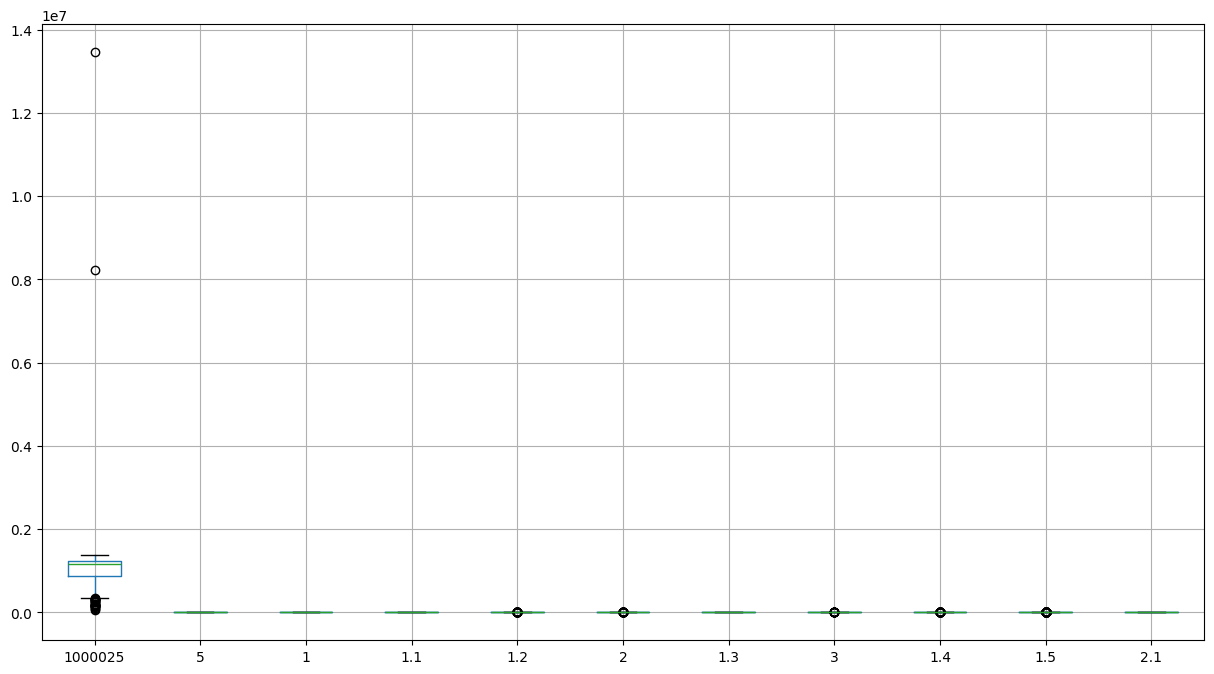

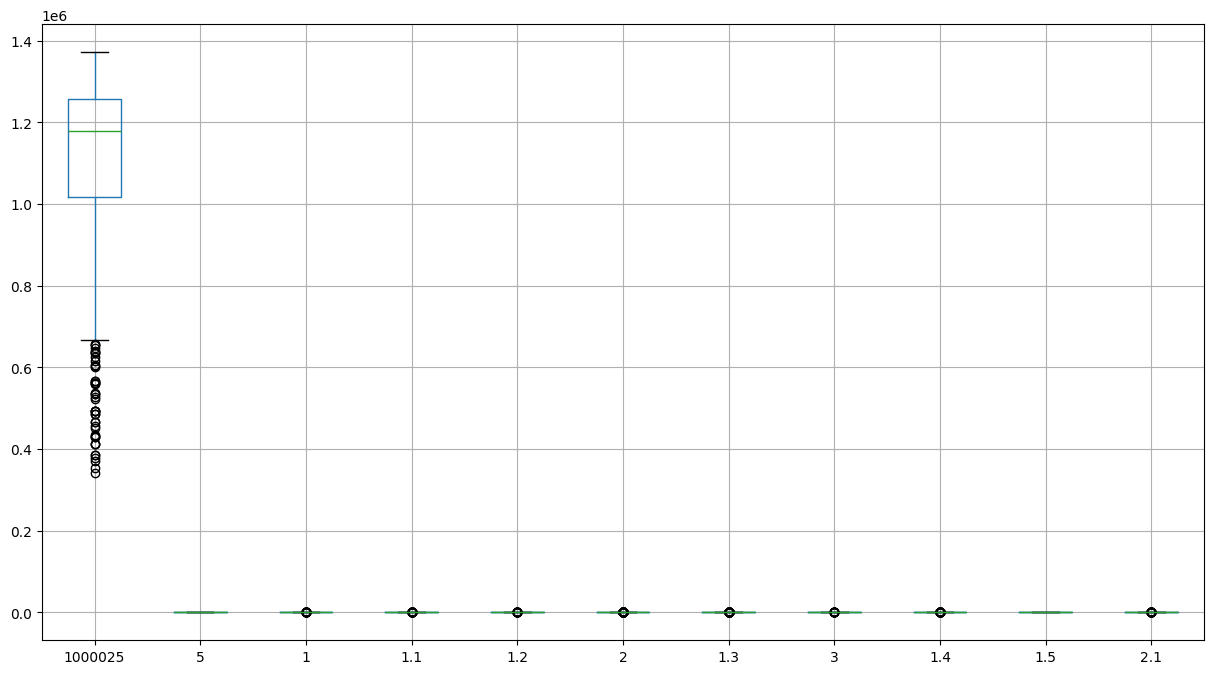

Logistic Regression Accuracy :  0.9473684210526315
Naive Bayes Accuracy :  0.968421052631579


In [ ]:
import pandas as pd
import numpy as np

# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("BreastCancerWc.csv")

df.head()
df.info()

# ============================================
# DATA CLEANING
# ============================================

# Replace ? with NaN
df.replace("?", np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

df.info()

# Remove negative values from numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

df = df[(df[numeric_cols] >= 0).all(axis=1)]

df.info()

# ============================================
# OUTLIER DETECTION & REMOVAL
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
df.boxplot()
plt.show()

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lowerlimit = Q1 - 1.5 * IQR
upperlimit = Q3 + 1.5 * IQR

df = df[~((df[numeric_cols] < lowerlimit) |
          (df[numeric_cols] > upperlimit)).any(axis=1)]

df.shape

plt.figure(figsize=(15,8))
df.boxplot()
plt.show()

# ============================================
# DATA TRANSFORMATION
# ============================================

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Convert categorical values into numeric
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

# ============================================
# TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_predict = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predict)

print("Logistic Regression Accuracy : ", lr_accuracy)

# ============================================
# NAIVE BAYES
# ============================================

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_predict = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predict)

print("Naive Bayes Accuracy : ", nb_accuracy)